In [5]:
# scripts/build_tiles_5km.py
import geopandas as gpd, shapely, json, pathlib
REG = gpd.read_file("Regions_December_2024_Boundaries_EN_BGC_-3699623982958172124.geojson").to_crs(27700)

In [12]:
# append bounds
REG.merge(right=REG.bounds, left_index=True, right_index=True)

,FID,RGN24CD,RGN24NM,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,minx,miny,maxx,maxy
0,1,E12000001,North East,417315,600357,-1.728870,55.29702,12201951-50af-4e67-bd5e-bc5e19b04b9b,"MULTIPOLYGON (((450272.012 525912.804, 450135....",356180.383567,506235.704961,478433.407506,657539.283859
1,2,E12000002,North West,350014,506279,-2.772390,54.44944,0a07bcad-79b5-41b4-8e47-7ab3831f733d,"MULTIPOLYGON (((327828.625 373756.175, 327839....",293941.442220,338994.107005,406087.208971,588517.293912
2,3,E12000003,Yorkshire and The Humber,446902,448736,-1.287140,53.93265,1e65ebb6-acff-4cfd-b6e5-5e3dca036baa,"MULTIPOLYGON (((495485.81 422529.606, 496086.6...",363191.662637,378564.298861,542151.156997,519002.013497
3,4,E12000004,East Midlands,477658,322635,-0.849710,52.79572,ec7a03af-0d6a-41a5-90f4-6a93e9b22d34,"MULTIPOLYGON (((552995.415 326666.556, 552916....",397827.872425,231283.099082,557489.812820,414654.699183
4,5,E12000005,West Midlands,386293,295477,-2.203600,52.55697,42e5f029-56ae-4947-ac95-ee7f44a564cc,"POLYGON ((403380.622 368321.323, 403508.882 36...",316113.812400,214364.501408,456472.513455,369909.506992
5,6,E12000006,East of England,571076,263235,0.504178,52.24073,11865ded-43ee-4d72-b16e-32ad5da0e51d,"MULTIPOLYGON (((570606.953 181367.874, 570558....",486504.032932,175098.150914,655653.865746,346771.821706
6,7,E12000007,London,517517,178394,-0.308630,51.49229,9cd5cec9-fa74-4bdc-b4a5-91ac2a0efcfb,"MULTIPOLYGON (((516084.987 172495.064, 516122....",503577.512669,155854.315397,561956.709318,200933.605976
7,8,E12000008,South East,470064,172925,-0.993090,51.45099,83b83902-d369-421d-a016-26b418854ddd,"MULTIPOLYGON (((429024.529 84821.197, 428968.9...",403098.613627,75258.752611,640164.812551,256160.144362
8,9,E12000009,South West,285016,102566,-3.633420,50.81119,f459acca-1472-47f1-bac1-b0f83db429f8,"MULTIPOLYGON (((83999.706 5358.603, 83889.796 ...",82668.525424,5352.603364,435920.051585,246052.208576


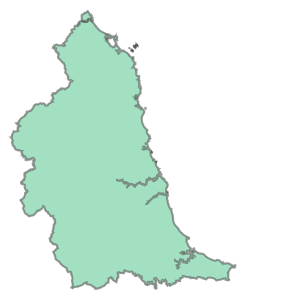

In [21]:
REG.geometry[0]

In [ ]:
# UK_EW  = REG[REG['ctry22nm'].isin(['England','Wales'])].unary_union
# xmin, ymin, xmax, ymax = REG.bounds
step = 5_000            # 5 km squares

bboxes = []
for i in range(REG.shape[0]): # cycle through each region
    xmin, ymin, xmax, ymax = REG.bounds.iloc[i, :] # get bounds for that region
    for x in range(int(xmin), int(xmax), step):
        for y in range(int(ymin), int(ymax), step):
            tile = shapely.box(x, y, x+step, y+step)
            if tile.intersects(REG.geometry[i]):
                bboxes.append({"bbox": f"{x},{y},{x+step},{y+step}", "rgn24cd": REG.at[i, 'RGN24CD']})



pathlib.Path("tiles_5km_ew.json").write_text(json.dumps(bboxes))


187732

In [9]:
REG.bounds

,minx,miny,maxx,maxy
0,356180.383567,506235.704961,478433.407506,657539.283859
1,293941.442220,338994.107005,406087.208971,588517.293912
2,363191.662637,378564.298861,542151.156997,519002.013497
3,397827.872425,231283.099082,557489.812820,414654.699183
4,316113.812400,214364.501408,456472.513455,369909.506992
5,486504.032932,175098.150914,655653.865746,346771.821706
6,503577.512669,155854.315397,561956.709318,200933.605976
7,403098.613627,75258.752611,640164.812551,256160.144362
8,82668.525424,5352.603364,435920.051585,246052.208576
